In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


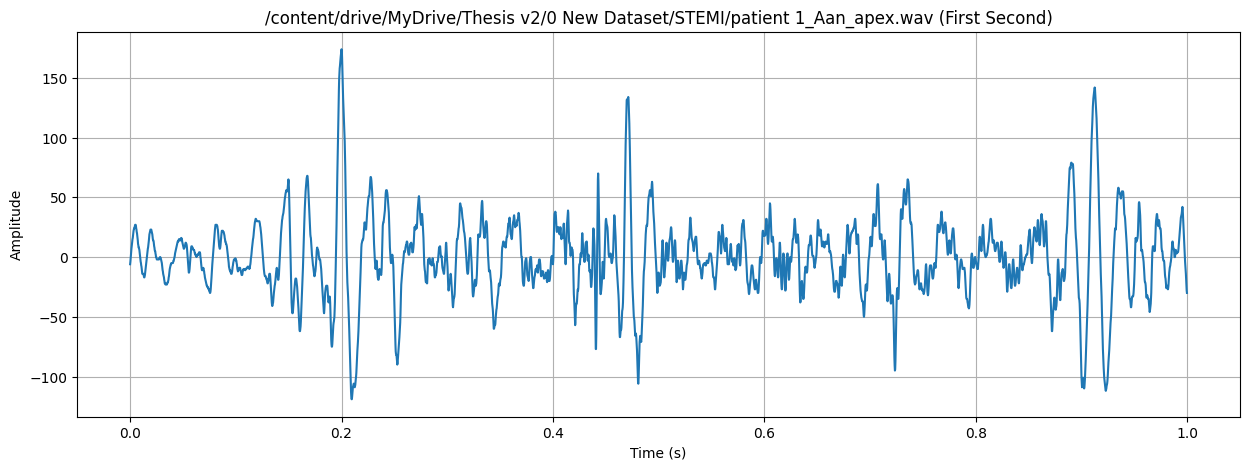

In [ ]:
import wave
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

directory_path = '/content/drive/MyDrive/Thesis v2/0 New Dataset/STEMI/'

# Specify the file pattern with a wildcard
file_pattern = 'patient 1_*_apex.wav'

# Construct the full path pattern
full_path_pattern = os.path.join(directory_path, file_pattern)

# Find all files matching the pattern
matching_files = glob.glob(full_path_pattern)
matching_files_string = ', '.join(matching_files)

try:
    # Open the WAV file
    with wave.open(matching_files_string, 'rb') as wf:
        # Get audio file properties
        num_channels = wf.getnchannels()
        sample_width = wf.getsampwidth()
        frame_rate = wf.getframerate()
        num_frames = wf.getnframes()

        # Read all frames
        frames = wf.readframes(num_frames)

        # Convert frames to numpy array
        # Assuming 16-bit audio (typical for WAV)
        if sample_width == 2:
            audio_data = np.frombuffer(frames, dtype=np.int16)
        elif sample_width == 1:
            audio_data = np.frombuffer(frames, dtype=np.uint8)
        else:
            raise ValueError("Unsupported sample width")

        # If stereo, take the first channel
        if num_channels > 1:
            audio_data = audio_data[::num_channels]

        # Create a time axis
        time = np.linspace(0, num_frames / frame_rate, num_frames if num_channels == 1 else num_frames // num_channels)

        # Plot the waveform (first second only)
        plt.figure(figsize=(15, 5))
        # Calculate the number of samples in the first second
        samples_in_first_second = frame_rate
        plt.plot(time[:samples_in_first_second], audio_data[:samples_in_first_second])
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude')
        plt.title(f'{matching_files_string} (First Second)')
        plt.grid(True)
        plt.show()

except FileNotFoundError:
    print(f"Error: File not found at {matching_files_string}")
except wave.Error as e:
    print(f"Error reading WAV file: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

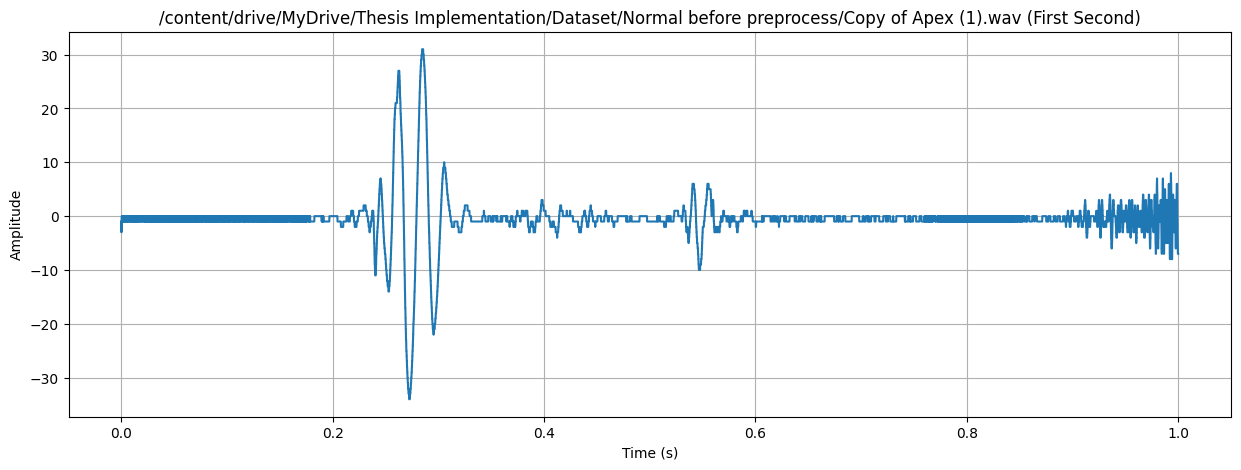

In [ ]:
import wave
import matplotlib.pyplot as plt
import numpy as np

directory_path = '/content/drive/MyDrive/Thesis Implementation/Dataset/Normal before preprocess/'

# Specify the file pattern with a wildcard
file_pattern = 'Copy of Apex (*).wav'

# Construct the full path pattern
full_path_pattern = os.path.join(directory_path, file_pattern)

# Find all files matching the pattern
matching_files = glob.glob(full_path_pattern)
matching_files_string = ', '.join(matching_files)

try:
    # Open the WAV file
    with wave.open(matching_files_string, 'rb') as wf:
        # Get audio file properties
        num_channels = wf.getnchannels()
        sample_width = wf.getsampwidth()
        frame_rate = wf.getframerate()
        num_frames = wf.getnframes()

        # Read all frames
        frames = wf.readframes(num_frames)

        # Convert frames to numpy array
        # Assuming 16-bit audio (typical for WAV)
        if sample_width == 2:
            audio_data = np.frombuffer(frames, dtype=np.int16)
        elif sample_width == 1:
            audio_data = np.frombuffer(frames, dtype=np.uint8)
        else:
            raise ValueError("Unsupported sample width")

        # If stereo, take the first channel
        if num_channels > 1:
            audio_data = audio_data[::num_channels]

        # Create a time axis
        time = np.linspace(0, num_frames / frame_rate, num_frames if num_channels == 1 else num_frames // num_channels)

        # Plot the waveform (first second only)
        plt.figure(figsize=(15, 5))
        # Calculate the number of samples in the first second
        samples_in_first_second = frame_rate
        plt.plot(time[:samples_in_first_second], audio_data[:samples_in_first_second])
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude')
        plt.title(f'{matching_files_string} (First Second)')
        plt.grid(True)
        plt.show()

except FileNotFoundError:
    print(f"Error: File not found at {matching_files_string}")
except wave.Error as e:
    print(f"Error reading WAV file: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [ ]:
%pip install noisereduce scipy

In [ ]:
directory_path = '/content/drive/MyDrive/Thesis v2/0 New Dataset/STEMI/'
file_pattern = 'patient 1_*_apex.wav'
full_path_pattern = os.path.join(directory_path, file_pattern)
matching_files = glob.glob(full_path_pattern)

audio_data_list = []

for file_path in matching_files:
    try:
        with wave.open(file_path, 'rb') as wf:
            num_channels = wf.getnchannels()
            sample_width = wf.getsampwidth()
            frame_rate = wf.getframerate()
            num_frames = wf.getnframes()

            frames = wf.readframes(num_frames)

            if sample_width == 2:
                audio_data = np.frombuffer(frames, dtype=np.int16)
            elif sample_width == 1:
                audio_data = np.frombuffer(frames, dtype=np.uint8)
            else:
                print(f"Unsupported sample width {sample_width} for file: {file_path}")
                continue

            if num_channels > 1:
                audio_data = audio_data[::num_channels]

            audio_data_list.append({
                'file_path': file_path,
                'audio_data': audio_data,
                'frame_rate': frame_rate,
                'num_channels': num_channels,
                'sample_width': sample_width,
                'num_frames': num_frames
            })
            print(f"Successfully loaded {file_path}")

    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except wave.Error as e:
        print(f"Error reading WAV file {file_path}: {e}")
    except Exception as e:
        print(f"An unexpected error occurred for file {file_path}: {e}")

if audio_data_list:
    print(f"Loaded data for {len(audio_data_list)} files.")
else:
    print("No audio files were loaded.")


Successfully loaded /content/drive/MyDrive/Thesis v2/0 New Dataset/STEMI/patient 1_Aan_apex.wav
Loaded data for 1 files.


In [ ]:
import noisereduce as nr

for audio_info in audio_data_list:
    audio_data = audio_info['audio_data']
    frame_rate = audio_info['frame_rate']

    # Apply noise reduction
    # We assume stationary noise for simplicity and estimate noise from the audio itself.
    # In a real-world scenario, you might want to capture a noise-only segment.
    # Set time_mask_smooth_ms to a value greater than or equal to the required minimum (64ms)
    reduced_noise_audio = nr.reduce_noise(y=audio_data, sr=frame_rate, stationary=True, time_mask_smooth_ms=100)

    # Store the noise-reduced audio data
    audio_info['audio_data_reduced'] = reduced_noise_audio

    print(f"Applied noise reduction to {audio_info['file_path']}")

if audio_data_list:
    print("Noise reduction applied to all loaded files.")
else:
    print("No audio data was available for noise reduction.")

Applied noise reduction to /content/drive/MyDrive/Thesis v2/0 New Dataset/STEMI/patient 1_Aan_apex.wav
Noise reduction applied to all loaded files.


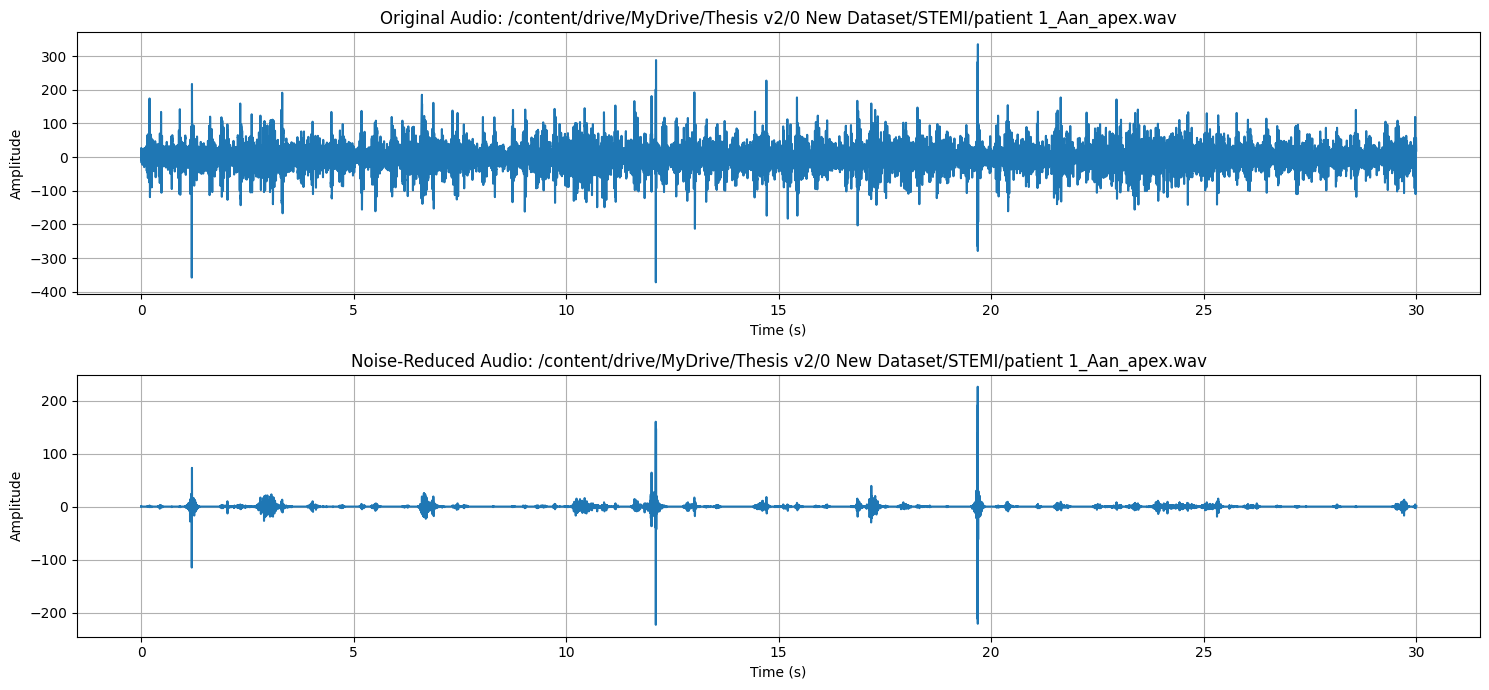

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming audio_data_list contains the loaded audio data with 'audio_data' (original) and 'audio_data_reduced' (noise-reduced)

if audio_data_list:
    for audio_info in audio_data_list:
        original_audio = audio_info['audio_data']
        reduced_noise_audio = audio_info['audio_data_reduced']
        frame_rate = audio_info['frame_rate']
        file_path = audio_info['file_path']

        # Create time axis
        time = np.linspace(0, len(original_audio) / frame_rate, len(original_audio))

        # Plot the waveforms
        plt.figure(figsize=(15, 7))

        plt.subplot(2, 1, 1)
        plt.plot(time, original_audio)
        plt.title(f'Original Audio: {file_path}')
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude')
        plt.grid(True)

        plt.subplot(2, 1, 2)
        plt.plot(time, reduced_noise_audio)
        plt.title(f'Noise-Reduced Audio: {file_path}')
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude')
        plt.grid(True)

        plt.tight_layout()
        plt.show()
else:
    print("No audio data available to visualize.")

In [ ]:
directory_path_normal = '/content/drive/MyDrive/Thesis Implementation/Dataset/Normal before preprocess/'
file_name_normal = 'Copy of Apex (1).wav'
full_path_normal = os.path.join(directory_path_normal, file_name_normal)

normal_audio_info = {}

try:
    with wave.open(full_path_normal, 'rb') as wf:
        num_channels_normal = wf.getnchannels()
        sample_width_normal = wf.getsampwidth()
        frame_rate_normal = wf.getframerate()
        num_frames_normal = wf.getnframes()

        frames_normal = wf.readframes(num_frames_normal)

        if sample_width_normal == 2:
            audio_data_normal = np.frombuffer(frames_normal, dtype=np.int16)
        elif sample_width_normal == 1:
            audio_data_normal = np.frombuffer(frames_normal, dtype=np.uint8)
        else:
            print(f"Unsupported sample width {sample_width_normal} for file: {full_path_normal}")
            audio_data_normal = None

        if audio_data_normal is not None and num_channels_normal > 1:
            audio_data_normal = audio_data_normal[::num_channels_normal]

        if audio_data_normal is not None:
            normal_audio_info = {
                'file_path': full_path_normal,
                'audio_data': audio_data_normal,
                'frame_rate': frame_rate_normal,
                'num_channels': num_channels_normal,
                'sample_width': sample_width_normal,
                'num_frames': num_frames_normal
            }
            print(f"Successfully loaded {full_path_normal}")

except FileNotFoundError:
    print(f"Error: File not found at {full_path_normal}")
except wave.Error as e:
    print(f"Error reading WAV file {full_path_normal}: {e}")
except Exception as e:
    print(f"An unexpected error occurred for file {full_path_normal}: {e}")

if normal_audio_info:
    print("Normal audio file loaded successfully.")
else:
    print("Failed to load normal audio file.")


Successfully loaded /content/drive/MyDrive/Thesis Implementation/Dataset/Normal before preprocess/Copy of Apex (1).wav
Normal audio file loaded successfully.


In [ ]:
import librosa

# Compute ZCR for normal audio
if normal_audio_info:
    audio_data_normal_float = normal_audio_info['audio_data'].astype(float)
    frame_rate_normal = normal_audio_info['frame_rate']
    # Ensure the audio data is at least 1D
    if audio_data_normal_float.ndim > 1:
        audio_data_normal_float = audio_data_normal_float[:, 0] # Assuming mono or taking the first channel

    zcr_normal = librosa.feature.zero_crossing_rate(y=audio_data_normal_float, frame_length=2048, hop_length=512)
    normal_audio_info['zcr'] = zcr_normal
    print(f"Computed ZCR for normal audio: {normal_audio_info['file_path']}")
else:
    print("Normal audio data not available to compute ZCR.")


# Compute ZCR for noise-reduced NSTEMI audio
if audio_data_list:
    for audio_info in audio_data_list:
        if 'audio_data_reduced' in audio_info:
            audio_data_reduced_float = audio_info['audio_data_reduced'].astype(float)
            frame_rate_reduced = audio_info['frame_rate']

            # Ensure the audio data is at least 1D
            if audio_data_reduced_float.ndim > 1:
                audio_data_reduced_float = audio_data_reduced_float[:, 0] # Assuming mono or taking the first channel

            zcr_reduced = librosa.feature.zero_crossing_rate(y=audio_data_reduced_float, frame_length=2048, hop_length=512)
            audio_info['zcr_reduced'] = zcr_reduced
            print(f"Computed ZCR for noise-reduced audio: {audio_info['file_path']}")
        else:
            print(f"Noise-reduced audio data not available for {audio_info['file_path']} to compute ZCR.")
else:
    print("No NSTEMI audio data available to compute ZCR.")


Computed ZCR for normal audio: /content/drive/MyDrive/Thesis Implementation/Dataset/Normal before preprocess/Copy of Apex (1).wav
Computed ZCR for noise-reduced audio: /content/drive/MyDrive/Thesis v2/0 New Dataset/STEMI/patient 1_Aan_apex.wav


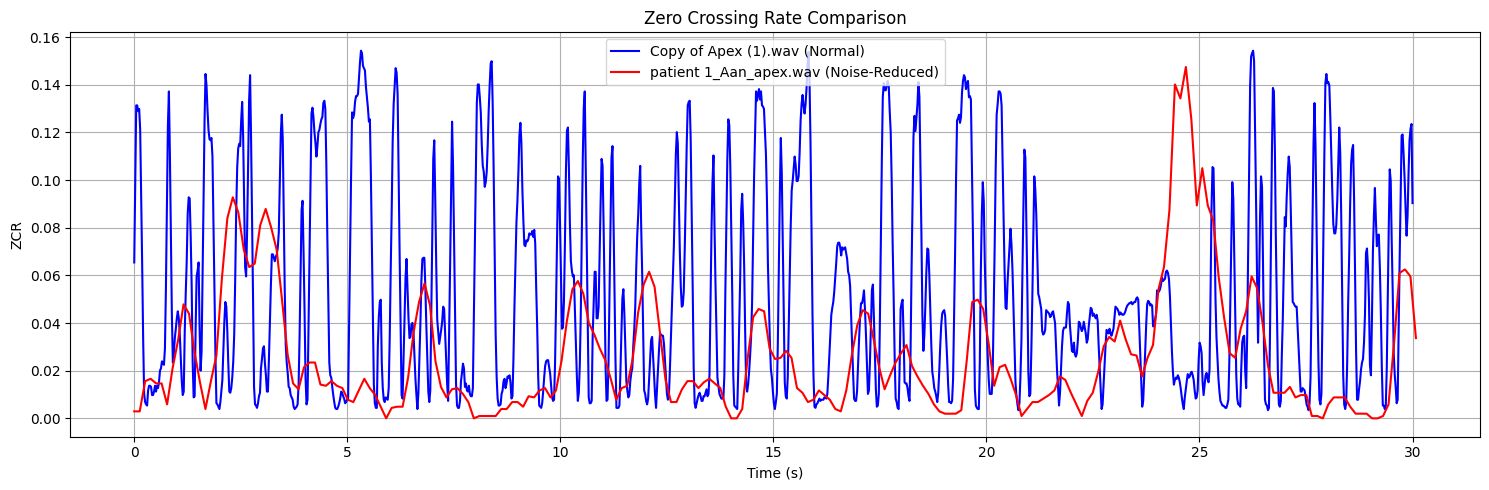

In [ ]:
# Check if data is available
if normal_audio_info and audio_data_list:
    # Extract data for normal audio
    zcr_normal = normal_audio_info.get('zcr')
    frame_rate_normal = normal_audio_info.get('frame_rate')
    file_path_normal = normal_audio_info.get('file_path', 'Normal Audio')

    # Extract data for noise-reduced NSTEMI audio
    # Assuming we are plotting the first NSTEMI file in the list for comparison
    if audio_data_list:
        audio_info_reduced = audio_data_list[0]
        zcr_reduced = audio_info_reduced.get('zcr_reduced')
        frame_rate_reduced = audio_info_reduced.get('frame_rate')
        file_path_reduced = audio_info_reduced.get('file_path', 'Noise-Reduced NSTEMI Audio')
    else:
        zcr_reduced = None
        frame_rate_reduced = None
        file_path_reduced = 'Noise-Reduced NSTEMI Audio'


    if zcr_normal is not None and frame_rate_normal is not None and zcr_reduced is not None and frame_rate_reduced is not None:
        # Define hop length used in ZCR calculation
        hop_length = 512

        # Calculate time axis for normal ZCR
        time_normal = np.linspace(0, len(zcr_normal[0]) * hop_length / frame_rate_normal, len(zcr_normal[0]))

        # Calculate time axis for noise-reduced ZCR
        time_reduced = np.linspace(0, len(zcr_reduced[0]) * hop_length / frame_rate_reduced, len(zcr_reduced[0]))


        # Create plot
        plt.figure(figsize=(15, 5))

        plt.plot(time_normal, zcr_normal[0], label=f'{os.path.basename(file_path_normal)} (Normal)', color='blue')
        plt.plot(time_reduced, zcr_reduced[0], label=f'{os.path.basename(file_path_reduced)} (Noise-Reduced)', color='red')

        plt.title('Zero Crossing Rate Comparison')
        plt.xlabel('Time (s)')
        plt.ylabel('ZCR')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()
    else:
        print("Zero-crossing rate data is not available for plotting.")
else:
    print("Normal or NSTEMI audio data is not available.")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Check if data is available
if normal_audio_info and audio_data_list:
    # Extract data for normal audio
    zcr_normal = normal_audio_info.get('zcr')
    frame_rate_normal = normal_audio_info.get('frame_rate')
    file_path_normal = normal_audio_info.get('file_path', 'Normal Audio')

    # Extract data for original NSTEMI audio
    # Assuming we are plotting the first NSTEMI file in the list for comparison
    if audio_data_list and 'zcr_original' in audio_data_list[0]:
        audio_info_original_nstemi = audio_data_list[0]
        zcr_original_nstemi = audio_info_original_nstemi.get('zcr_original')
        frame_rate_original_nstemi = audio_info_original_nstemi.get('frame_rate')
        file_path_original_nstemi = audio_info_original_nstemi.get('file_path', 'Original NSTEMI Audio')
    else:
        zcr_original_nstemi = None
        frame_rate_original_nstemi = None
        file_path_original_nstemi = 'Original NSTEMI Audio'


    if zcr_normal is not None and frame_rate_normal is not None and zcr_original_nstemi is not None and frame_rate_original_nstemi is not None:
        # Define hop length used in ZCR calculation
        hop_length = 512

        # Calculate time axis for normal ZCR
        time_normal = np.linspace(0, len(zcr_normal[0]) * hop_length / frame_rate_normal, len(zcr_normal[0]))

        # Calculate time axis for original NSTEMI ZCR
        time_original_nstemi = np.linspace(0, len(zcr_original_nstemi[0]) * hop_length / frame_rate_original_nstemi, len(zcr_original_nstemi[0]))


        # Create plot
        plt.figure(figsize=(15, 5))

        plt.plot(time_normal, zcr_normal[0], label=f'{os.path.basename(file_path_normal)} (Normal)', color='blue')
        plt.plot(time_original_nstemi, zcr_original_nstemi[0], label=f'{os.path.basename(file_path_original_nstemi)} (Original NSTEMI)', color='green')

        plt.title('Zero Crossing Rate Comparison (Original NSTEMI vs Normal)')
        plt.xlabel('Time (s)')
        plt.ylabel('ZCR')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()
    else:
        print("Zero-crossing rate data is not available for plotting.")
else:
    print("Normal or NSTEMI audio data is not available.")

Zero-crossing rate data is not available for plotting.


In [ ]:
import wave
import numpy as np
import os

directory_path_myocardial = '/content/drive/MyDrive/Thesis Implementation/Dataset/Myocardial/'
file_name_myocardial = 'Copy of APEX.wav'
full_path_myocardial = os.path.join(directory_path_myocardial, file_name_myocardial)

myocardial_audio_info = {}

try:
    with wave.open(full_path_myocardial, 'rb') as wf:
        num_channels_myocardial = wf.getnchannels()
        sample_width_myocardial = wf.getsampwidth()
        frame_rate_myocardial = wf.getframerate()
        num_frames_myocardial = wf.getnframes()

        frames_myocardial = wf.readframes(num_frames_myocardial)

        if sample_width_myocardial == 2:
            audio_data_myocardial = np.frombuffer(frames_myocardial, dtype=np.int16)
        elif sample_width_myocardial == 1:
            audio_data_myocardial = np.frombuffer(frames_myocardial, dtype=np.uint8)
        else:
            print(f"Unsupported sample width {sample_width_myocardial} for file: {full_path_myocardial}")
            audio_data_myocardial = None

        if audio_data_myocardial is not None and num_channels_myocardial > 1:
            audio_data_myocardial = audio_data_myocardial[::num_channels_myocardial]

        if audio_data_myocardial is not None:
            myocardial_audio_info = {
                'file_path': full_path_myocardial,
                'audio_data': audio_data_myocardial,
                'frame_rate': frame_rate_myocardial,
                'num_channels': num_channels_myocardial,
                'sample_width': sample_width_myocardial,
                'num_frames': num_frames_myocardial
            }
            print(f"Successfully loaded {full_path_myocardial}")

except FileNotFoundError:
    print(f"Error: File not found at {full_path_myocardial}")
except wave.Error as e:
    print(f"Error reading WAV file {full_path_myocardial}: {e}")
except Exception as e:
    print(f"An unexpected error occurred for file {full_path_myocardial}: {e}")

if myocardial_audio_info:
    print("Myocardial audio file loaded successfully.")
else:
    print("Failed to load myocardial audio file.")

Successfully loaded /content/drive/MyDrive/Thesis Implementation/Dataset/Myocardial/Copy of APEX.wav
Myocardial audio file loaded successfully.


## Calculate Zero Crossing Rate for Myocardial Audio

### Subtask:
Compute the zero-crossing rate for the loaded myocardial audio.

**Reasoning**:
Compute the zero-crossing rate for the myocardial audio using the loaded data.

In [ ]:
import librosa

# Compute ZCR for myocardial audio
if myocardial_audio_info:
    audio_data_myocardial_float = myocardial_audio_info['audio_data'].astype(float)
    frame_rate_myocardial = myocardial_audio_info['frame_rate']

    # Ensure the audio data is at least 1D
    if audio_data_myocardial_float.ndim > 1:
        audio_data_myocardial_float = audio_data_myocardial_float[:, 0] # Assuming mono or taking the first channel

    zcr_myocardial = librosa.feature.zero_crossing_rate(y=audio_data_myocardial_float, frame_length=2048, hop_length=512)
    myocardial_audio_info['zcr'] = zcr_myocardial
    print(f"Computed ZCR for myocardial audio: {myocardial_audio_info['file_path']}")
else:
    print("Myocardial audio data not available to compute ZCR.")

Computed ZCR for myocardial audio: /content/drive/MyDrive/Thesis Implementation/Dataset/Myocardial/Copy of APEX.wav


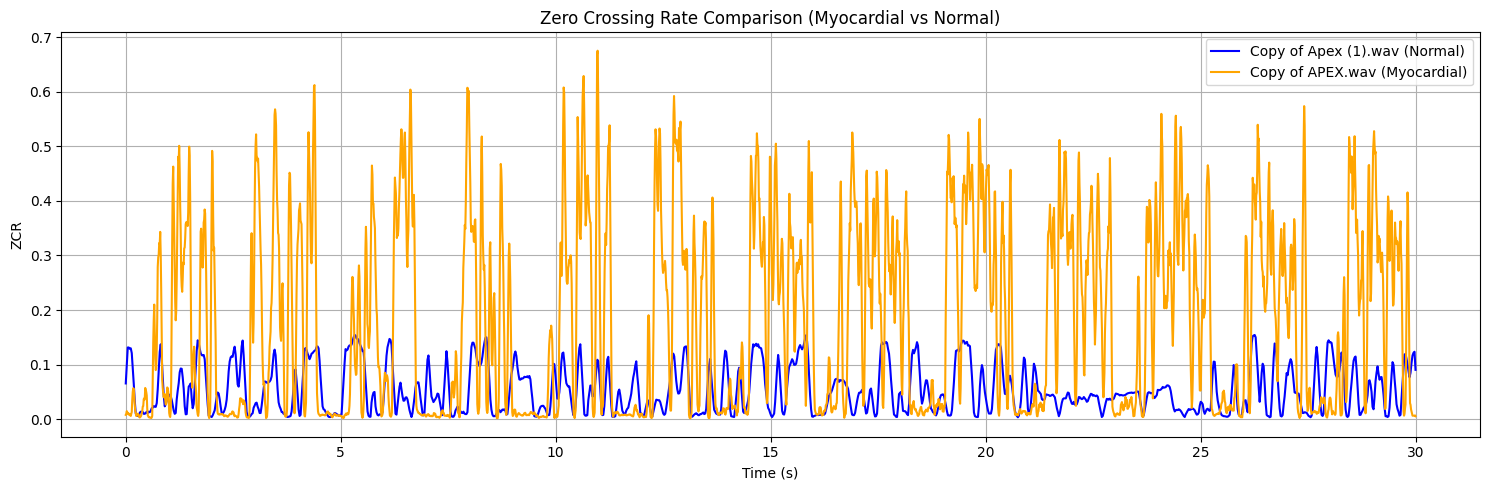

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Check if data is available
if normal_audio_info and myocardial_audio_info:
    # Extract data for normal audio
    zcr_normal = normal_audio_info.get('zcr')
    frame_rate_normal = normal_audio_info.get('frame_rate')
    file_path_normal = normal_audio_info.get('file_path', 'Normal Audio')

    # Extract data for myocardial audio
    zcr_myocardial = myocardial_audio_info.get('zcr')
    frame_rate_myocardial = myocardial_audio_info.get('frame_rate')
    file_path_myocardial = myocardial_audio_info.get('file_path', 'Myocardial Audio')


    if zcr_normal is not None and frame_rate_normal is not None and zcr_myocardial is not None and frame_rate_myocardial is not None:
        # Define hop length used in ZCR calculation
        hop_length = 512

        # Calculate time axis for normal ZCR
        time_normal = np.linspace(0, len(zcr_normal[0]) * hop_length / frame_rate_normal, len(zcr_normal[0]))

        # Calculate time axis for myocardial ZCR
        time_myocardial = np.linspace(0, len(zcr_myocardial[0]) * hop_length / frame_rate_myocardial, len(zcr_myocardial[0]))


        # Create plot
        plt.figure(figsize=(15, 5))

        plt.plot(time_normal, zcr_normal[0], label=f'{os.path.basename(file_path_normal)} (Normal)', color='blue')
        plt.plot(time_myocardial, zcr_myocardial[0], label=f'{os.path.basename(file_path_myocardial)} (Myocardial)', color='orange')

        plt.title('Zero Crossing Rate Comparison (Myocardial vs Normal)')
        plt.xlabel('Time (s)')
        plt.ylabel('ZCR')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()
    else:
        print("Zero-crossing rate data is not available for plotting.")
else:
    print("Normal or Myocardial audio data is not available.")

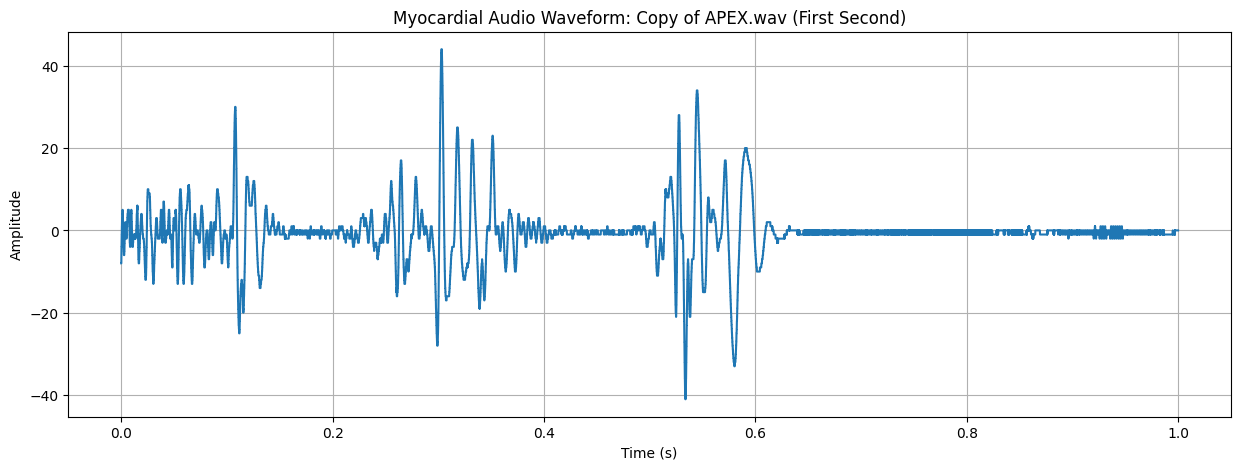

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Check if myocardial audio data is available
if myocardial_audio_info and 'audio_data' in myocardial_audio_info:
    audio_data = myocardial_audio_info['audio_data']
    frame_rate = myocardial_audio_info['frame_rate']
    file_path = myocardial_audio_info['file_path']

    # Create time axis
    time = np.linspace(0, len(audio_data) / frame_rate, len(audio_data))

    # Plot the waveform (first second only)
    plt.figure(figsize=(15, 5))
    # Calculate the number of samples in the first second
    samples_in_first_second = frame_rate
    plt.plot(time[:samples_in_first_second], audio_data[:samples_in_first_second])
    plt.title(f'Myocardial Audio Waveform: {os.path.basename(file_path)} (First Second)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.show()
else:
    print("Myocardial audio data is not available for visualization.")